In [1]:
import sqlite3

# Connect to a new database (or existing one)
conn = sqlite3.connect('sales_data.db')
cursor = conn.cursor()

# Create table
cursor.execute('''
CREATE TABLE IF NOT EXISTS sales (
    id INTEGER PRIMARY KEY AUTOINCREMENT,
    product TEXT,
    quantity INTEGER,
    price REAL
)
''')

# Insert sample data
data = [
    ('Apple', 10, 2.5),
    ('Banana', 15, 1.2),
    ('Apple', 5, 2.5),
    ('Orange', 8, 3.0),
    ('Banana', 10, 1.2),
]

cursor.executemany("INSERT INTO sales (product, quantity, price) VALUES (?, ?, ?)", data)
conn.commit()
conn.close()


  product  total_qty  revenue
0   Apple         15     37.5
1  Banana         25     30.0
2  Orange          8     24.0


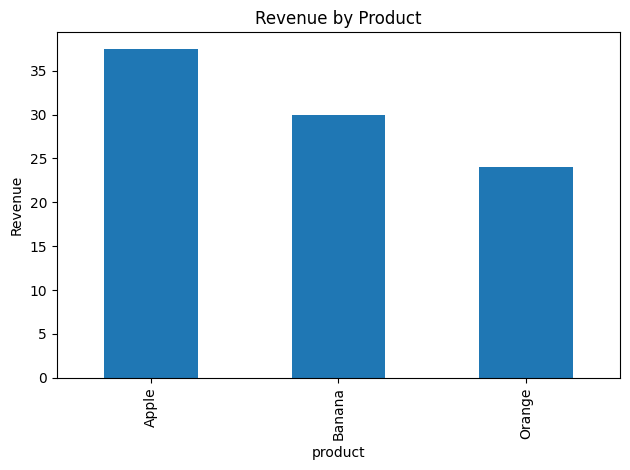

In [2]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

# Connect to database
conn = sqlite3.connect('sales_data.db')

# SQL query
query = '''
SELECT product,
       SUM(quantity) AS total_qty,
       SUM(quantity * price) AS revenue
FROM sales
GROUP BY product
'''

# Load into pandas
df = pd.read_sql_query(query, conn)

# Print result
print(df)

# Plot bar chart
df.plot(kind='bar', x='product', y='revenue', legend=False)
plt.title("Revenue by Product")
plt.ylabel("Revenue")
plt.tight_layout()
plt.savefig("sales_chart.png")  # Optional: Save chart as image
plt.show()

conn.close()
